In [18]:
import numpy as np
import pandas as pd
import arviz as az
from matplotlib import pyplot as plt
from matplotlib import patches
from scipy import stats
from cmdstanpy import CmdStanModel
from sampler import CycloneSampler, CycloneDataSimulator

In [3]:
def plot_parameter_estimation_mcmc(Sampler, DataSimulator, param_names, N_obs):
    N_samples = len(Sampler.alpha_draws)

    # save real parameters
    true_params = [
        DataSimulator.sig2,
        DataSimulator.Beta,
        DataSimulator.tau2,
        DataSimulator.alpha, 
        DataSimulator.gamma,
        DataSimulator.nu,
        DataSimulator.lam
    ]
    true_params_flat = np.concatenate([np.atleast_1d(p).flatten() for p in true_params])
    all_param_draws = np.vstack([
        Sampler.sig2_draws.T,
        Sampler.Beta_draws.reshape(N_samples, -1).T,
        Sampler.tau2_draws.T,
        Sampler.alpha_draws, 
        Sampler.gamma_draws,
        Sampler.nu_draws.T,
        Sampler.lam_draws.T,
    ])

    unscaled_param_draws = all_param_draws.copy()

    param_stds = all_param_draws.std(axis=1)
    all_param_draws = ((all_param_draws.T - true_params_flat) / param_stds).T

    # I got help from Claude to make this plot because I didn't know how to plot all the parameters together in a nice way
    fig = plt.figure(figsize=(14, 7))
    fig.suptitle(f"Convergence of Posterior Parameter Draws, n={N_obs} simulated observations",
                fontsize=13, fontweight='bold', y=1.01)
    ax = fig.add_subplot(111)

    # --- Boxplot ---
    ax.boxplot(
        all_param_draws.T,
        tick_labels=param_names,
        whis=(5, 95),
        showfliers=False,
        medianprops=dict(color='steelblue', linewidth=1.5),
        boxprops=dict(color='steelblue'),
        whiskerprops=dict(color='steelblue'),
        capprops=dict(color='steelblue'),
    )
    ax.axhline(0, color='red', linestyle='--', linewidth=1, label='True value')
    ax.set_ylabel("Std. Deviations from True Value", fontsize=10)
    ax.tick_params(axis='x', rotation=90)
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.set_xlim(0.5, len(param_names) + 0.5)
        
    plt.show()

    return true_params_flat, unscaled_param_draws

In [17]:
def compare_posterior_draws(draws1, draws2, true_params, param_names, labels, title, figsize=(14, 7), y_lim=(-8, 8), save_file=None):

    n_params = len(draws1)
    positions = np.arange(n_params)

    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111)

    for i, (mcmc_draw, stan_draw) in enumerate(zip(draws1, draws2)):

        if true_params is not None:
            ref_val = true_params[i]
            # offset plot slightly left/right from the reference
            vp_mcmc = ax.violinplot([mcmc_draw - ref_val], 
                                    positions=[i-0.15], widths=0.25, showmeans=True, showmedians=False, showextrema=False)
            vp_stan = ax.violinplot([stan_draw - ref_val], 
                                    positions=[i+0.15], widths=0.25, showmeans=True, showmedians=False, showextrema=False)
        else:
            vp_mcmc = ax.violinplot([mcmc_draw], 
                                    positions=[i-0.15], widths=0.25, showmeans=True, showmedians=False, showextrema=False)
            vp_stan = ax.violinplot([stan_draw], 
                                    positions=[i+0.15], widths=0.25, showmeans=True, showmedians=False, showextrema=False)            
        
        # style the violin plots for each sampler
        for pc in vp_mcmc["bodies"]:
            pc.set_facecolor("#1f77b4")
            pc.set_alpha(0.5)
        vp_mcmc["cmeans"].set_color("#1f77b4")

        for pc in vp_stan["bodies"]:
            pc.set_facecolor("#ff7f0e")
            pc.set_alpha(0.5)
        vp_stan["cmeans"].set_color("#ff7f0e")

    # mark the reference values (0 because we centered the plot)
    if true_params is not None: ax.axhline(0, color="black", linewidth=1.2, linestyle="--", label="True value", zorder=5)

    # set ticks and labels
    ax.set_xticks(positions)
    ax.set_xticklabels(param_names, rotation=90)
    if true_params is not None: ax.set_ylabel("Deviation from True Value")
    else: ax.set_ylabel("Parameter Value")
    ax.set_title(title)

    ax.set_ylim(*y_lim)

    if true_params is not None:
        legend_handles = [
            patches.Patch(color='#1f77b4', alpha=0.7, label=labels[0]),
            patches.Patch(color='#ff7f0e', alpha=0.7, label=labels[1]),
            plt.Line2D([0], [0], color='black', linestyle='--', label='True value')
        ]
    else: 
        legend_handles = [
            patches.Patch(color='#1f77b4', alpha=0.7, label=labels[0]),
            patches.Patch(color='#ff7f0e', alpha=0.7, label=labels[1]),
        ]


    ax.legend(handles=legend_handles, loc="upper left")
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    if save_file is not None: plt.savefig(save_file, dpi=300)
    return fig, ax

Test sensitivity of our MCMC implementation.

In [42]:
# c# calibrated prior parameters
a = 3.
y_alpha, z_alpha = 2., 3./2.
y_gamma, z_gamma = 2., 4.
v2 = 100.
y_lam, z_lam = 2., 25.

# model parameters
B = 3               # number of ocean basins
D = 5               # number of predictors

In [43]:
N_small = 100             # number of observations

# simulate N observations from the model
DataSimulator = CycloneDataSimulator(
    B = B,
    a = a,
    y_alpha=y_alpha, z_alpha=z_alpha,
    y_gamma=y_gamma, z_gamma=z_gamma,
    v2=v2,
    y_lam=y_lam, z_lam=z_lam
)
DataSimulator.generate_X(N_sim=N_small)
X = DataSimulator.X 
basins = DataSimulator.basins
W = DataSimulator.simulate()

# save real parameters
real_params = [
    DataSimulator.sig2,
    DataSimulator.Beta,
    DataSimulator.tau2,
    DataSimulator.alpha, 
    DataSimulator.gamma,
    DataSimulator.nu,
    DataSimulator.lam
]

# get results using our own MCMC implementation
SmallSampler = CycloneSampler(
    W = W, X = X, basins = basins,
    a=a,
    y_alpha=y_alpha, z_alpha=z_alpha,
    y_gamma=y_gamma, z_gamma=z_gamma, 
    y_lam=y_lam, z_lam=z_lam,
    v2=v2,
    B=B
)
SmallSampler.sample(30_000, init_state=real_params)

In [44]:
N_big = 1500             # number of observations

# simulate N observations from the model
W = DataSimulator.redraw(N_big)
X = DataSimulator.X 
basins = DataSimulator.basins

# get results using our own MCMC implementation
BigSampler = CycloneSampler(
    W = W, X = X, basins = basins,
    a=a,
    y_alpha=y_alpha, z_alpha=z_alpha,
    y_gamma=y_gamma, z_gamma=z_gamma, 
    y_lam=y_lam, z_lam=z_lam,
    v2=v2,
    B=B
)
BigSampler.sample(30_000, init_state=real_params)

In [51]:
# extract draws into an array
# chop off burn-in!!
burn_in = 10_000
small_draws_array = np.vstack([
    SmallSampler.sig2_draws[burn_in:].T,
    SmallSampler.Beta_draws[burn_in:].reshape(30_000 - burn_in, -1).T,
    SmallSampler.tau2_draws[burn_in:].T,
    SmallSampler.alpha_draws[burn_in:], 
    SmallSampler.gamma_draws[burn_in:],
    SmallSampler.nu_draws[burn_in:].T,
    SmallSampler.lam_draws[burn_in:].T,
])

big_draws_array = np.vstack([
    BigSampler.sig2_draws[burn_in:].T,
    BigSampler.Beta_draws[burn_in:].reshape(30_000 - burn_in, -1).T,
    BigSampler.tau2_draws[burn_in:].T,
    BigSampler.alpha_draws[burn_in:], 
    BigSampler.gamma_draws[burn_in:],
    BigSampler.nu_draws[burn_in:].T,
    BigSampler.lam_draws[burn_in:].T,
])

In [47]:
param_names = [f"sig2[{b}]" for b in range(1, B+1)] + [f"Beta[{b},{d}]" for b in range(1, B+1) for d in range(1, D+1)] + [f"tau2[{d}]" for d in range(1, D+1)] + ["alpha", "gamma"] + [f"nu[{d}]" for d in range(1, D+1)] + [f"lambda[{d}]" for d in range(1, D+1)]
true_params_flat = np.concatenate([np.atleast_1d(p).flatten() for p in real_params])

(<Figure size 1400x700 with 1 Axes>,
 <Axes: title={'center': 'Sensitivity to Number of Observations'}, ylabel='Deviation from True Value'>)

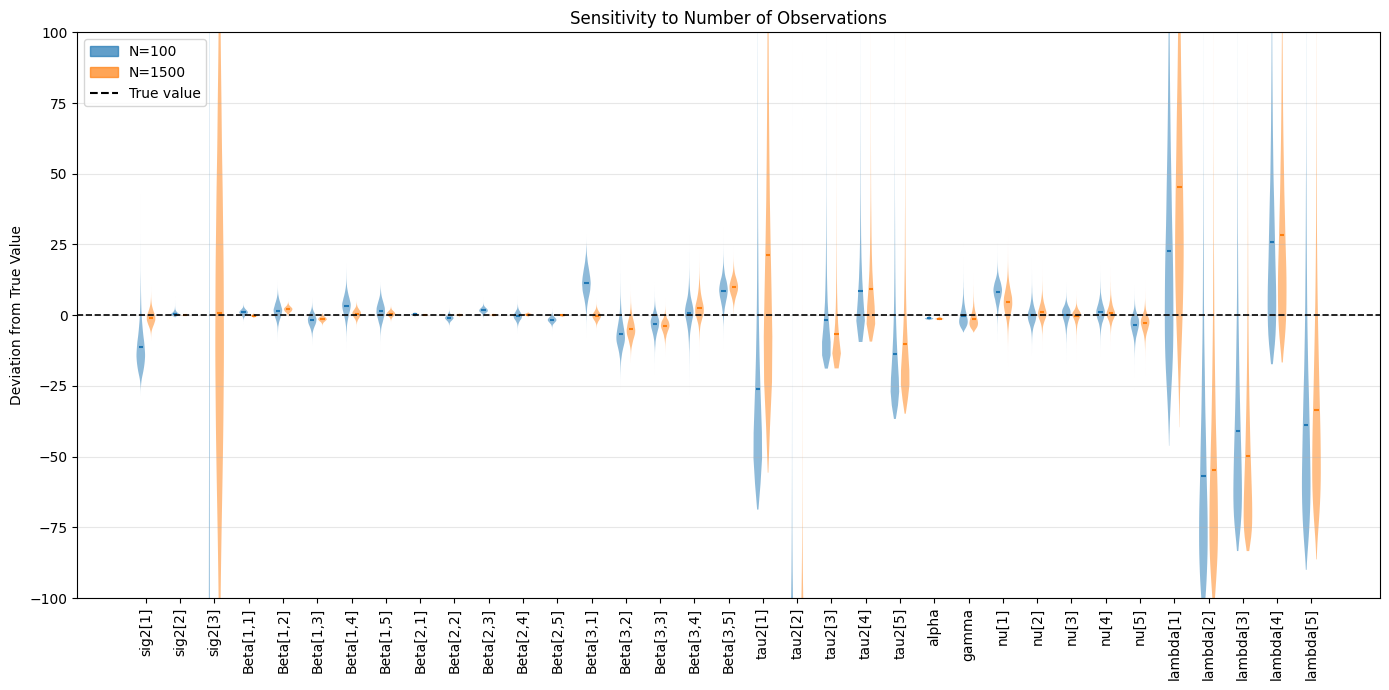

In [54]:
compare_posterior_draws(small_draws_array, big_draws_array, true_params_flat, param_names, y_lim=(-100, 100),
                        labels=[f"N={N_small}", f"N={N_big}"], title="Sensitivity to Number of Observations",
                        save_file="../figures/sensitivity_num_observations.png")

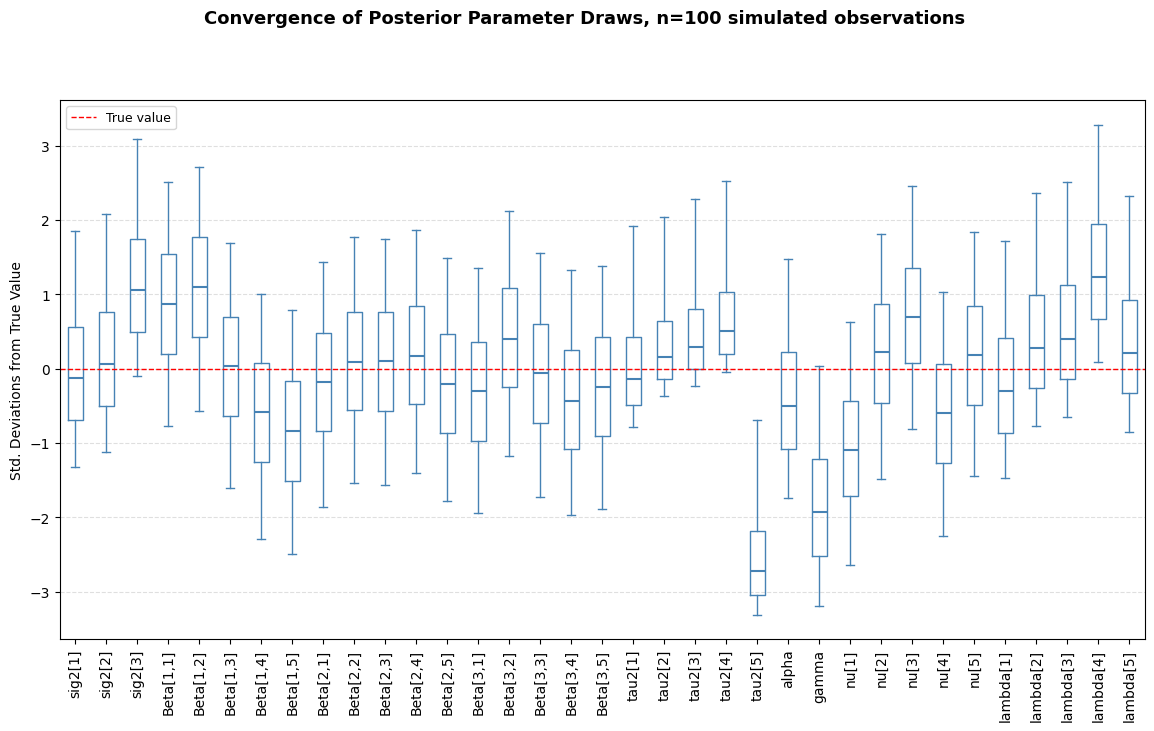

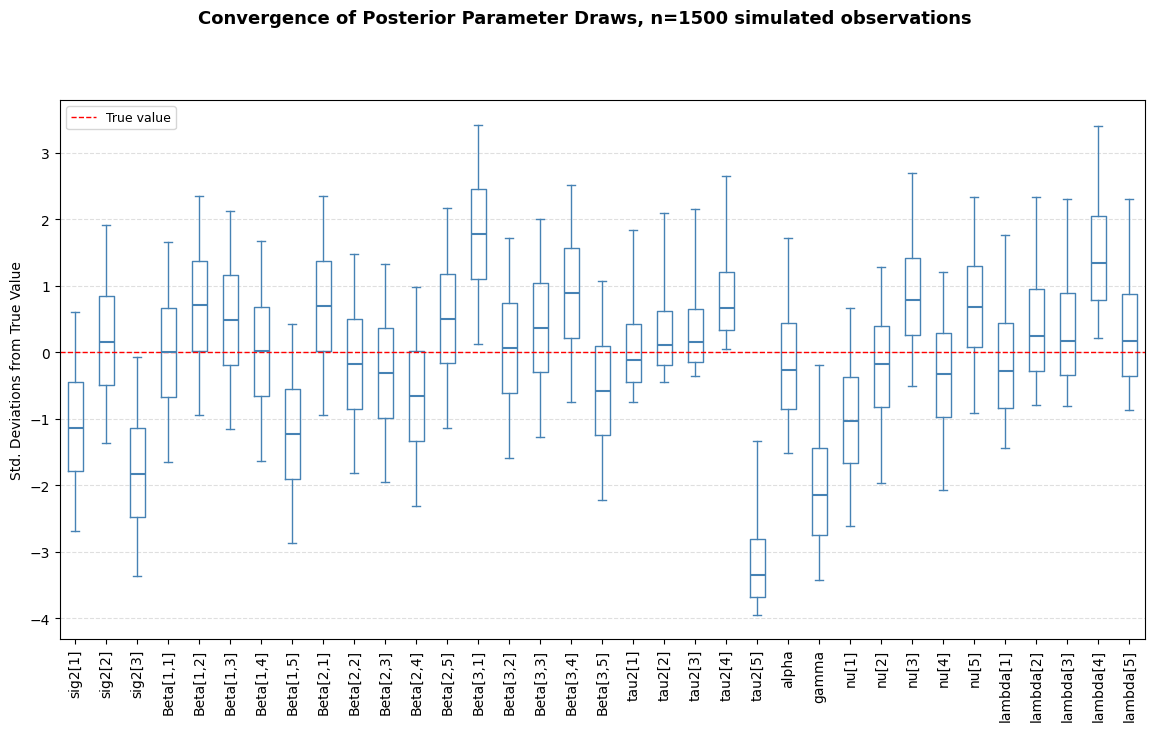

In [112]:
param_names = [f"sig2[{b}]" for b in range(1, B+1)] + [f"Beta[{b},{d}]" for b in range(1, B+1) for d in range(1, D+1)] + [f"tau2[{d}]" for d in range(1, D+1)] + ["alpha", "gamma"] + [f"nu[{d}]" for d in range(1, D+1)] + [f"lambda[{d}]" for d in range(1, D+1)]

true_params, draws_small = plot_parameter_estimation_mcmc(SmallSampler, DataSimulator, param_names, N_small)
_, draws_big = plot_parameter_estimation_mcmc(BigSampler, DataSimulator, param_names, N_big)

In [118]:
# tabulate results
small_parameter_estimation = pd.DataFrame({
    "True Value" : true_params,
    "Posterior Mean" : draws_small.mean(axis=1),
    "Posterior STD" : draws_small.std(axis=1),
    "Posterior 5-th Percentile" : np.percentile(draws_small, 5, axis=1),
    "Posterior 95-th Percentile" : np.percentile(draws_small, 95, axis=1),
}, index=param_names)

big_parameter_estimation = pd.DataFrame({
    "True Value" : true_params,
    "Posterior Mean" : draws_big.mean(axis=1),
    "Posterior STD" : draws_big.std(axis=1),
    "Posterior 5-th Percentile" : np.percentile(draws_big, 5, axis=1),
    "Posterior 95-th Percentile" : np.percentile(draws_big, 95, axis=1),
}, index=param_names)

In [119]:
small_parameter_estimation

,True Value,Posterior Mean,Posterior STD,Posterior 5-th Percentile,Posterior 95-th Percentile
sig2[1],2.303413,2.315610,0.605213,1.504360,3.423857
sig2[2],5.412897,5.723239,1.467415,3.765312,8.458775
sig2[3],2.735219,4.057880,1.092308,2.621810,6.101136
"Beta[1,1]",-1.943865,-1.730583,0.244724,-2.132512,-1.329260
"Beta[1,2]",0.674578,1.416703,0.681327,0.282869,2.519111
"Beta[1,3]",-2.727562,-2.708677,0.584598,-3.667822,-1.743870
"Beta[1,4]",0.142872,-0.547868,1.140103,-2.466376,1.285171
"Beta[1,5]",0.235019,-0.379800,0.732603,-1.587824,0.810957
"Beta[2,1]",1.049488,0.972022,0.410288,0.288727,1.640413
"Beta[2,2]",1.826968,1.919670,0.899522,0.448430,3.415569


In [114]:
big_parameter_estimation

,True Value,Posterior Mean,Posterior STD,Posterior 5-th Percentile,Posterior 95-th Percentile
0,2.303413,2.153402,0.136348,1.937398,2.385243
1,5.412897,5.480342,0.346760,4.937216,6.075737
2,2.735219,2.457077,0.155712,2.211570,2.723555
3,-1.943865,-1.943764,0.067232,-2.054444,-1.832454
4,0.674578,0.832039,0.225531,0.460668,1.202543
5,-2.727562,-2.637010,0.186462,-2.942319,-2.331121
6,0.142872,0.146668,0.330765,-0.397976,0.694028
7,0.235019,-0.021482,0.208497,-0.362575,0.324259
8,1.049488,1.121863,0.104133,0.951108,1.293723
9,1.826968,1.768638,0.329465,1.228212,2.311708


Conclusions:
- Due to the large number of parameters, the model needs a large number of observations (ideally 500+ per ocean basin) in order to converge well.
- With a large number of observations, the posterior parameter draws almost always capture the true value within the 95% credible region.
- When given a large number of observations, the posterior standard deviation shrinks significantly.
- The model recovers predictor-specific parameters more accurately when we choose to model a larger number of ocean basins. However, we are limited to 3 because this is what our data reflects. This is one inherent weakness in the identifiability of our model. 

Test sensitivty to prior parameters

In [56]:
# c# calibrated prior parameters
a = 3.
y_alpha, z_alpha = 2., 3./2.
y_gamma, z_gamma = 2., 4.
v2 = 100.
y_lam, z_lam = 2., 25.

# model parameters
B = 3               # number of ocean basins
D = 5               # number of predictors

In [57]:
N = 500             # number of observations

# simulate N observations from the model
DataSimulator = CycloneDataSimulator(
    B = B,
    a = a,
    y_alpha=y_alpha, z_alpha=z_alpha,
    y_gamma=y_gamma, z_gamma=z_gamma,
    v2=v2,
    y_lam=y_lam, z_lam=z_lam
)
DataSimulator.generate_X(N_sim=N)
X = DataSimulator.X 
basins = DataSimulator.basins
W = DataSimulator.simulate()

# save real parameters
real_params = [
    DataSimulator.sig2,
    DataSimulator.Beta,
    DataSimulator.tau2,
    DataSimulator.alpha, 
    DataSimulator.gamma,
    DataSimulator.nu,
    DataSimulator.lam
]

In [58]:
# get results using our real prior parameters
TrueSampler = CycloneSampler(
    W = W, X = X, basins = basins,
    a=a,
    y_alpha=y_alpha, z_alpha=z_alpha,
    y_gamma=y_gamma, z_gamma=z_gamma, 
    y_lam=y_lam, z_lam=z_lam,
    v2=v2,
    B=B
)
TrueSampler.sample(20_000, init_state=real_params)

In [59]:
# get results using a prior with bad prior parameters
# make some gamma priors overly confident and some very weakly informative
a = 8.
y_alpha, z_alpha = 5., 1./2.
y_gamma, z_gamma = 1., 8.
v2 = 1000.               # give parameters a big variance
y_lam, z_lam = 4., 25.

In [60]:
# get results using our real prior parameters
PerturbedSampler = CycloneSampler(
    W = W, X = X, basins = basins,
    a=a,
    y_alpha=y_alpha, z_alpha=z_alpha,
    y_gamma=y_gamma, z_gamma=z_gamma, 
    y_lam=y_lam, z_lam=z_lam,
    v2=v2,
    B=B
)
PerturbedSampler.sample(20_000, init_state=real_params)

In [61]:
# extract draws into an array
# chop off burn-in!!
burn_in = 1000
true_draws_array = np.vstack([
    TrueSampler.sig2_draws[burn_in:].T,
    TrueSampler.Beta_draws[burn_in:].reshape(20_000 - burn_in, -1).T,
    TrueSampler.tau2_draws[burn_in:].T,
    TrueSampler.alpha_draws[burn_in:], 
    TrueSampler.gamma_draws[burn_in:],
    TrueSampler.nu_draws[burn_in:].T,
    TrueSampler.lam_draws[burn_in:].T,
])

perturbed_draws_array = np.vstack([
    PerturbedSampler.sig2_draws[burn_in:].T,
    PerturbedSampler.Beta_draws[burn_in:].reshape(20_000 - burn_in, -1).T,
    PerturbedSampler.tau2_draws[burn_in:].T,
    PerturbedSampler.alpha_draws[burn_in:], 
    PerturbedSampler.gamma_draws[burn_in:],
    PerturbedSampler.nu_draws[burn_in:].T,
    PerturbedSampler.lam_draws[burn_in:].T,
])

In [62]:
param_names = [f"sig2[{b}]" for b in range(1, B+1)] + [f"Beta[{b},{d}]" for b in range(1, B+1) for d in range(1, D+1)] + [f"tau2[{d}]" for d in range(1, D+1)] + ["alpha", "gamma"] + [f"nu[{d}]" for d in range(1, D+1)] + [f"lambda[{d}]" for d in range(1, D+1)]
true_params_flat = np.concatenate([np.atleast_1d(p).flatten() for p in real_params])

(<Figure size 1400x700 with 1 Axes>,
 <Axes: title={'center': 'Sensitivity to Prior Parameters'}, ylabel='Deviation from True Value'>)

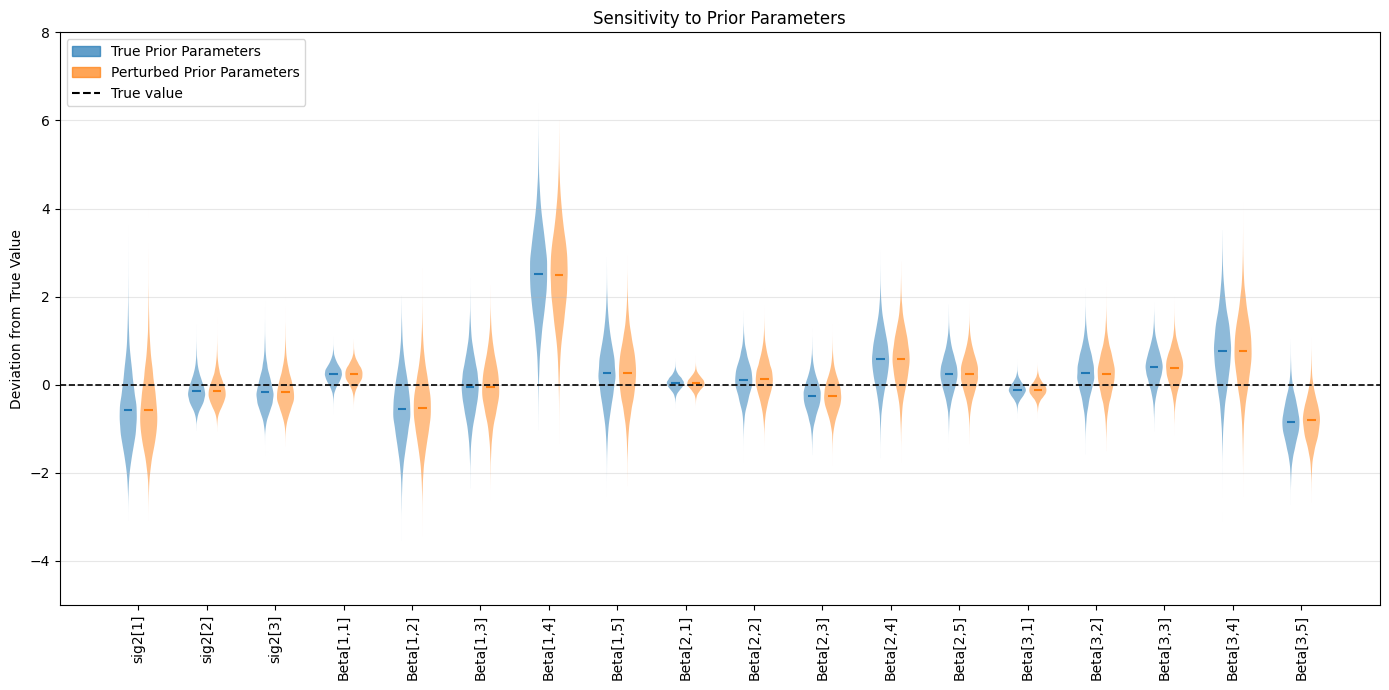

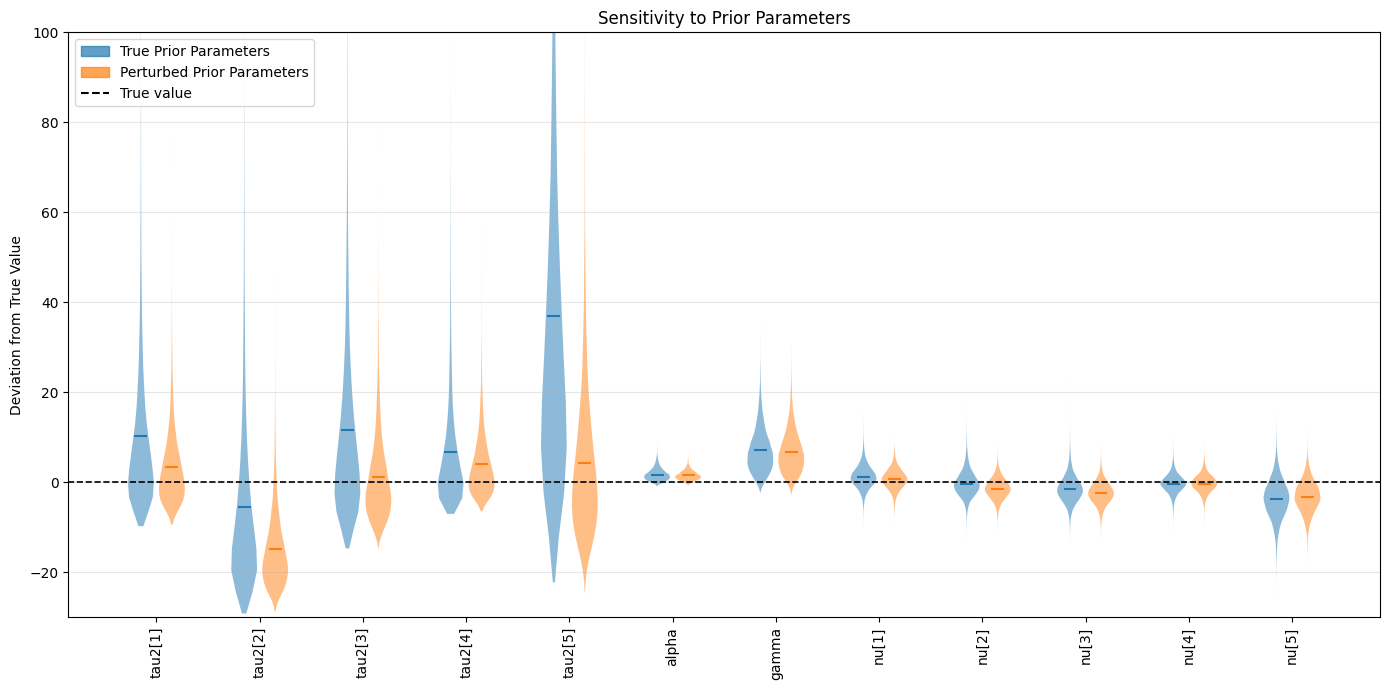

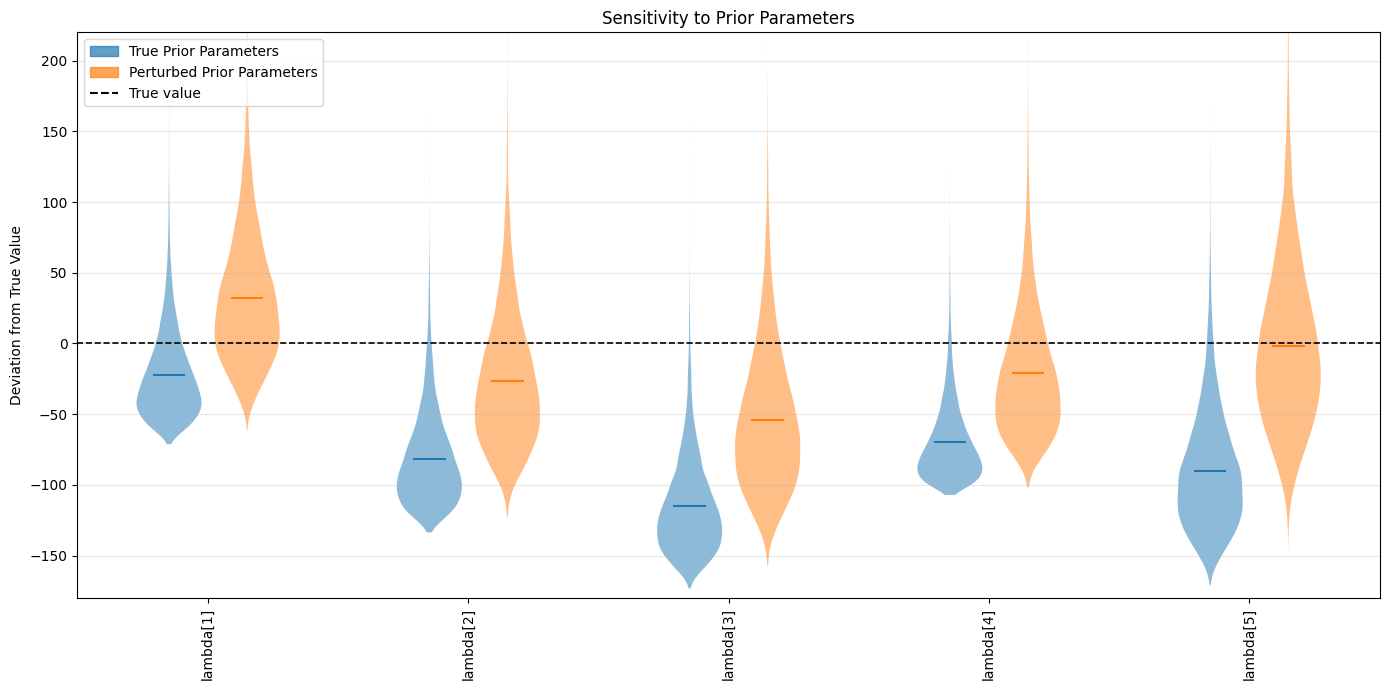

In [63]:
compare_posterior_draws(true_draws_array[:18], perturbed_draws_array[:18], true_params_flat[:18], param_names[:18], y_lim=(-5, 8),
                        labels=["True Prior Parameters", "Perturbed Prior Parameters"], title="Sensitivity to Prior Parameters", 
                        save_file="../figures/sensitivity_prior_params_1.png")
compare_posterior_draws(true_draws_array[18:-5], perturbed_draws_array[18:-5], true_params_flat[18:-5], param_names[18:-5], y_lim=(-30, 100),
                        labels=["True Prior Parameters", "Perturbed Prior Parameters"], title="Sensitivity to Prior Parameters",
                        save_file="../figures/sensitivity_prior_params_2.png")
compare_posterior_draws(true_draws_array[-5:], perturbed_draws_array[-5:], true_params_flat[-5:], param_names[-5:], y_lim=(-180, 220),
                        labels=["True Prior Parameters", "Perturbed Prior Parameters"], title="Sensitivity to Prior Parameters",
                        save_file="../figures/sensitivity_prior_params_3.png")

In [64]:
print(real_params)

[array([7.65794383, 2.82332339, 3.64563766]), array([[-13.43587584, -20.32720107, -16.33895045,  -0.66591481,
          2.34156216],
       [ -6.16615377, -16.37471698,  -6.2883415 ,   2.46757933,
         14.15506766],
       [-11.56661564, -12.50759559, -14.55095978,  -1.2852876 ,
         -7.93602067]]), array([11.67118028, 31.06382456, 17.59326895,  7.24989691, 34.4477237 ]), np.float64(1.190896942511522), np.float64(2.9123678583776327), array([-10.93687653, -14.9184204 ,  -9.81407066,   1.75429821,
         5.90710227]), array([ 73.77720372, 137.42458018, 175.75006003, 107.94487888,
       177.26023473])]
